<a href="https://colab.research.google.com/github/Harukokoko/Haruka-Nakagawa/blob/main/%E2%98%85uncomtrade_DLdata_HS10_2021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ダウンロードデータバージョン。
UNComtradeのAPIはいつrejectされるかわからないので、UNComtradeのサイトから無料ダウンロードしたデータ（HS：HS10、Periods：2023、輸出国：All・相手国：All、TradeFlow：Export、Mode of Transport：TOTAL modes of transport、Customs Codes：TOTAL customs procedure codes）を使用


## 0. 準備

In [169]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Callable
import scipy as sp
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import io
import os
from google.colab import files

## 1-1. データダウンロード

## 1-1-1. 今回はExcelでダウンロードしたデータをとりあえず使う

In [170]:
# 手動でダウンロード
uploaded = files.upload()

Saving ex_2021_all_all_HS8482_dlbyfree.xlsx to ex_2021_all_all_HS8482_dlbyfree.xlsx


## 1-2. データフレーム化

In [171]:
# アップロードされたファイル名を取得
file_name = list(uploaded.keys())[0]

# ExcelファイルをPandasデータフレームに変換
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# データフレームを確認
df.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20210101,2021,52,2021,20,AND,Andorra,X,...,30.000,False,0.0,False,NaN,1028.197,1028.197,0,False,True
1,C,A,20210101,2021,52,2021,20,AND,Andorra,X,...,30.000,False,0.0,False,NaN,1028.197,1028.197,0,False,True
2,C,A,20210101,2021,52,2021,24,AGO,Angola,X,...,78572.450,True,0.0,False,NaN,234222.389,234222.389,4,False,True
3,C,A,20210101,2021,52,2021,24,AGO,Angola,X,...,1057.624,True,0.0,False,NaN,19759.002,19759.002,6,False,True
4,C,A,20210101,2021,52,2021,24,AGO,Angola,X,...,114.000,False,0.0,False,NaN,95.020,95.020,0,False,True


##1-2　データ解説

### 抽出指定
商品データ、年次、HSコード、2023年、報告国は指定なし、品目は HSCode20_Cereals（第10塁　穀類）、輸出データ、貿易相手国は指定なし、積送国の指定なし、税関コード指定なし、貿易手段指定なし

## 1-2. データ概観

In [172]:
# 列名
print(df.columns)

Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
       'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
       'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code',
       'partner2ISO', 'partner2Desc', 'classificationCode',
       'classificationSearchCode', 'isOriginalClassification', 'cmdCode',
       'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc',
       'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty',
       'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
       'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt',
       'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue',
       'legacyEstimationFlag', 'isReported', 'isAggregate'],
      dtype='object')


In [173]:
#　データ数
print(df.shape)

(9749, 47)


In [174]:
# 国数
len(df['reporterDesc'].unique())

150

In [175]:
print(df['reporterDesc'].unique())

['Andorra' 'Angola' 'Azerbaijan' 'Argentina' 'Australia' 'Austria'
 'Bahamas' 'Bahrain' 'Armenia' 'Barbados' 'Belgium' 'Bermuda'
 'Bolivia (Plurinational State of)' 'Bosnia Herzegovina' 'Botswana'
 'Brazil' 'Belize' 'Brunei Darussalam' 'Bulgaria' 'Myanmar' 'Burundi'
 'Belarus' 'Cambodia' 'Cameroon' 'Canada' 'Cabo Verde' 'Sri Lanka' 'Chile'
 'China' 'Colombia' 'Congo' 'Dem. Rep. of the Congo' 'Costa Rica'
 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Benin' 'Denmark' 'Dominican Rep.'
 'Ecuador' 'El Salvador' 'Ethiopia' 'Estonia' 'Fiji' 'Finland' 'France'
 'French Polynesia' 'Djibouti' 'Gabon' 'Georgia' 'State of Palestine'
 'Germany' 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guyana' 'Honduras'
 'China, Hong Kong SAR' 'Hungary' 'Iceland' 'Indonesia' 'Iran' 'Ireland'
 'Israel' 'Italy' "Côte d'Ivoire" 'Jamaica' 'Japan' 'Kazakhstan' 'Jordan'
 'Kenya' 'Rep. of Korea' 'Kuwait' 'Kyrgyzstan' "Lao People's Dem. Rep."
 'Lebanon' 'Lesotho' 'Latvia' 'Liberia' 'Lithuania' 'Luxembourg'
 'China, Macao SAR' 'Mad

In [176]:
print(df['partnerDesc'].unique())

['World' 'Spain' 'Belgium' 'Dem. Rep. of the Congo' 'Ecuador' 'France'
 'Gabon' 'Italy' 'Namibia' 'Netherlands' 'Portugal' 'Qatar'
 'Saint Vincent and the Grenadines' 'Sao Tome and Principe' 'Saudi Arabia'
 'Singapore' 'South Africa' 'Sweden' 'United Kingdom' 'USA' 'Brazil'
 'Canada' 'China' 'Czechia' 'Georgia' 'Germany' 'Guyana'
 'China, Hong Kong SAR' 'Iran' 'Iraq' 'Kazakhstan' 'Malaysia' 'Mexico'
 'Nigeria' 'Norway' 'Russian Federation' 'Senegal' 'India'
 'United Arab Emirates' 'Türkiye' 'Turkmenistan' 'Ukraine' 'Egypt'
 'Bolivia (Plurinational State of)' 'Chile' 'Colombia' 'Paraguay' 'Peru'
 'Uruguay' 'Areas, nes' 'American Samoa' 'Argentina' 'Austria'
 'Bangladesh' 'Botswana' 'Solomon Isds' 'Brunei Darussalam' 'Bulgaria'
 'Myanmar' 'Cambodia' 'Sri Lanka' 'Congo' 'Denmark' 'Estonia' 'Fiji'
 'Finland' 'French Polynesia' 'Ghana' 'Kiribati' 'Guam' 'Guinea' 'Hungary'
 'Indonesia' 'Ireland' 'Israel' "Côte d'Ivoire" 'Japan' 'Kenya'
 'Rep. of Korea' 'Kuwait' "Lao People's Dem. Rep." 'Libe

今回のデータは11454件、139か国が含まれているが、どのように選んだのか不明なので要改善ではある

## 1-3 欠損値・外れ値処理

In [177]:
df.isnull().sum()

,0
typeCode,0
freqCode,0
refPeriodId,0
refYear,0
refMonth,0
period,0
reporterCode,0
reporterISO,0
reporterDesc,0
flowCode,0


**欠損値が50％以上ある列を削除**

In [178]:
# 欠損値の割合を計算
threshold = 0.5  # 50%以上が欠損している列を削除
df = df.loc[:, df.isna().mean() < threshold]

**reportedDescがWorldの行を削除する**

In [179]:
df = df[df['reporterDesc'] != 'world']
df = df[df['partnerDesc'] != 'world']
# 結果を確認
print(f"Number of rows after filtering: {len(df)}")

Number of rows after filtering: 9749


・小さい値にデータ数が集まっているので、不用意に削除すると鉱物輸出量が少ないだけで主要な国同士とのやり取りである行を削除する恐れがある

・今はデータ数減らしたくない

↓

一旦そのまま使う

# 2. ネットワーク可視化

## **▼データ全体のネットワーク化**

In [180]:
# 必要な列のみ抽出（必要に応じて列名を調整）
df = df[["reporterDesc", "partnerDesc", "fobvalue"]]

# FOB値が0以下の場合は除外
df = df[df["fobvalue"] > 0]

# 重複を統一するため、すべてのノード名を小文字に変換
df["reporterDesc"] = df["reporterDesc"].str.lower()
df["partnerDesc"] = df["partnerDesc"].str.lower()

# NetworkXのグラフ作成
G = nx.DiGraph()  # 有向グラフ

# ノードとエッジを追加
for _, row in df.iterrows():
    reporter = row["reporterDesc"]
    partner = row["partnerDesc"]
    weight = row["fobvalue"]

    # ノード追加（重複ノードは自動的に統一）
    G.add_node(reporter)
    G.add_node(partner)

    # エッジ追加（FOB値が0以上の場合のみ）
    if weight > 0:
        G.add_edge(reporter, partner, weight=weight)

# グラフの情報を表示
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 239
Number of edges: 7054


## **▼始点：中国→終点：アメリカ（距離４以下の経路）：subgraph**

In [181]:
# 基点と終点を設定
source_node = "china"
target_node = "usa"

# 距離4以下の経路を抽出
paths_within_distance = list(nx.all_simple_paths(G, source=source_node, target=target_node, cutoff=4))

# 距離4以下の経路に含まれるすべてのノードを抽出
nodes_within_paths = set(node for path in paths_within_distance for node in path)

# サブグラフを作成（抽出したノードのみ含む）
subgraph = G.subgraph(nodes_within_paths)

# カスタムレイアウトの計算（レイヤー構造にする）
pos = {}
layer_y = 1.0  # 最初のレイヤーの高さ（y座標）
layers = {}
for path in paths_within_distance:
    for distance, node in enumerate(path):
        if distance not in layers:
            layers[distance] = []
        if node not in layers[distance]:
            layers[distance].append(node)

for distance, nodes in sorted(layers.items()):
    layer_x = 0.5  # x座標の開始点
    spacing = 1.0 / len(nodes) if len(nodes) > 0 else 1.0  # レイヤー内のノード間隔
    for i, node in enumerate(nodes):
        pos[node] = (layer_x + i * spacing, layer_y)
    layer_y -= 0.2  # レイヤーを下げる

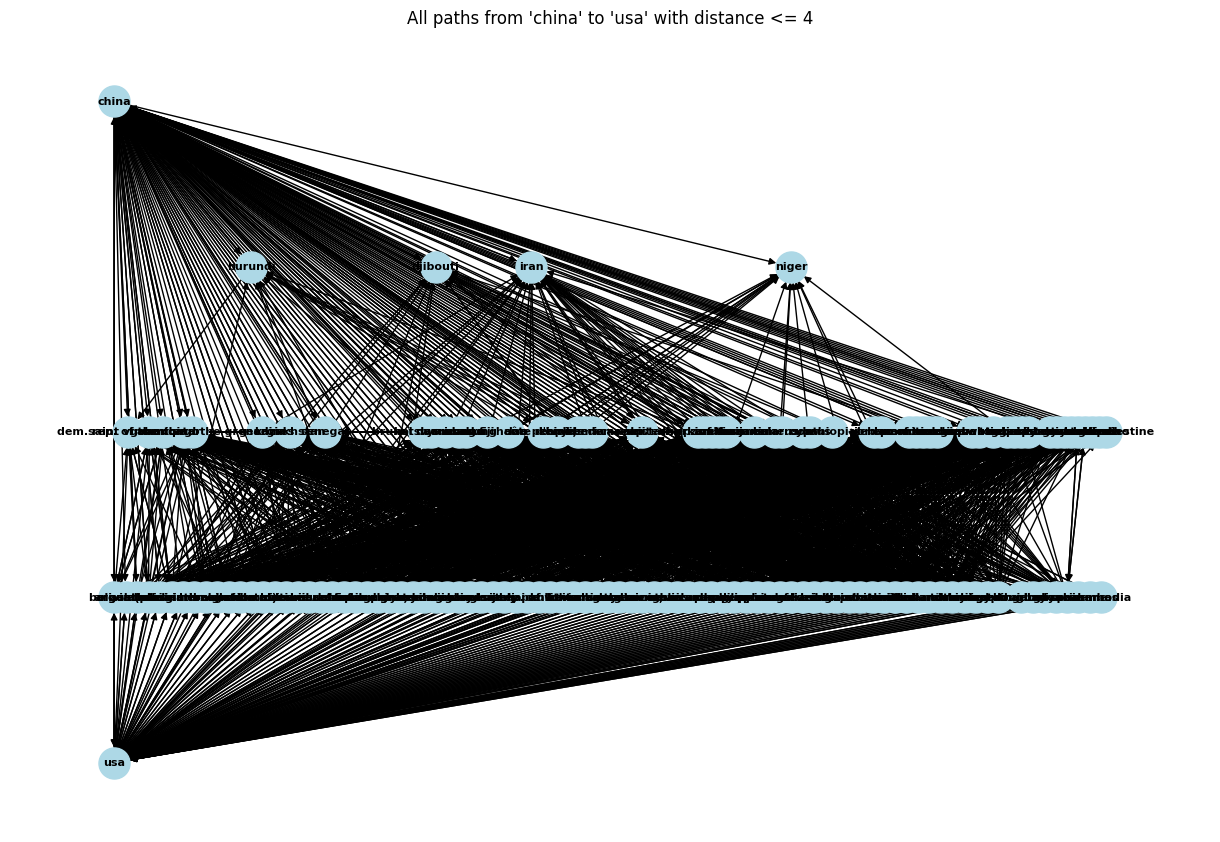

In [182]:
# グラフの描画
plt.figure(figsize=(12, 8))
nx.draw(
    subgraph,
    pos,
    with_labels=True,
    node_size=500,
    node_color="lightblue",
    font_weight="bold",
    font_size=8
)
plt.title(f"All paths from '{source_node}' to '{target_node}' with distance <= 4")
plt.axis('off')
plt.show()

「中国からアメリカまでの距離4以下の経路」はめっちゃある。
たぶんグラフ上のレイヤーが4つにわかれた経路がcentral african repを通るものしかないのは、同じ描画上同じレイヤーの国同士で貿易しているから。

In [183]:
# 中国からアメリカまで行くすべてのパスを列挙（最大距離を4に制限）
all_paths = list(nx.all_simple_paths(subgraph, source="china", target="usa", cutoff=4))

# 最も長いパス（ノード数が最大のパス）を取得
longest_path = max(all_paths, key=len)

# 最大パスのエッジ数を計算
max_path_length = len(longest_path) - 1  # ノード数から1を引いてエッジ数を計算

# 結果を表示
print(f"Longest path from 'china' to 'usa' (with max distance 10): {longest_path}")
print(f"Number of edges in the longest path: {max_path_length}")

Longest path from 'china' to 'usa' (with max distance 10): ['china', 'andorra', 'spain', 'angola', 'usa']
Number of edges in the longest path: 4


# 2.流入量計算＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊

## Networkxで計算

**閉路を削除する：subgraph→dag**


すべてのサイクルを除去してしまうと、china-usaのループがすべて削除されてしまうので、usa→chinaの向きのエッジを削除してからループを削除する。

**データクリーニングした（欠損値・外れ値削除、始点中国で終点アメリカに設定、閉路削除）DAG（Directed Acyclic Graph：有向非巡回グラフ）をcsv保存しておく：dag→df_cleaned**

In [184]:
print("ノードの数：", nx.number_of_nodes(G))
print("ノードの数：", nx.number_of_nodes(subgraph))
print("データの数 サイクル除去前：", df.shape[0])

ノードの数： 239
ノードの数： 147
データの数 サイクル除去前： 9749


サイクル除去するとデータが減りすぎる。

*   df：全データのデータフレーム
*   G：dfを基にreporter = row["reporterDesc"]、partner = row["partnerDesc"]、weight = row["fobvalue"]で作ったネットワーク
*   subgraph：始点china、終点usaとしたGの部分ネットワーク
*   dag：subgraphからサイクル除去（china→usaに影響しないエッジのみ削除）したもの
*   df_cleaned：dagのエッジリストをデータフレーム化したもの
*   subgraph_cleaned：subgraphからサイクル除去したもの（dag）

In [185]:
def calculate_flow_with_stop_on_target(G, source, target, weight='weight'):
    """
    始点から終点までの流入量を計算し、終点に到達したら計算を終了する関数。
    また、終点から始点へのエッジを削除する。

    Parameters:
        G (nx.DiGraph): 重み付き有向グラフ
        source (str): 始点ノード
        target (str): 終点ノード
        weight (str): 重み属性の名前

    Returns:
        float: 終点への最終流入量
    """
    # 終点から始点へのエッジを削除
    if G.has_edge(target, source):
        G = G.copy()  # オリジナルを変更しないためにコピー
        G.remove_edge(target, source)

    # 初期化: 各ノードの流入量を0に設定
    flow = {node: 0 for node in G.nodes}
    flow[source] = 1  # 始点の流入量を1に設定

    visited = set()  # 訪問済みノードを記録

    def dfs(node):
        if node == target:
            return  # 終点に到達したら終了

        visited.add(node)
        out_edges = G.out_edges(node, data=True)
        total_weight = sum(edge_data[weight] for _, _, edge_data in out_edges)

        if total_weight == 0:  # 出力がない場合
            return

        for _, neighbor, edge_data in out_edges:
            proportion = edge_data[weight] / total_weight
            if neighbor not in visited:
                flow[neighbor] += flow[node] * proportion
                dfs(neighbor)  # 再帰的に隣接ノードを処理

    # DFSを開始
    dfs(source)

    return flow.get(target, 0)

# アメリカへの最終流入量を計算
usa_flow = calculate_flow_with_stop_on_target(subgraph, source="china", target="usa", weight="weight")

# 結果を表示
print(f"The calculated flow into 'usa' from 'china' is: {usa_flow}")

The calculated flow into 'usa' from 'china' is: 0.11680671819877973


In [186]:
# 直接輸出割合を計算（元のサブグラフ）
if subgraph.has_edge(source_node, target_node):
    direct_weight = subgraph[source_node][target_node]["weight"]
    total_source_weight = sum(edge_data["weight"] for _, _, edge_data in subgraph.out_edges(source_node, data=True))
    direct_export_ratio1 = direct_weight / total_source_weight
else:
    direct_export_ratio1 = 0  # 直接輸出がない場合

# 直接輸出割合を表示
print(f"The direct export ratio from '{source_node}' to '{target_node}' in original subgraph is: {direct_export_ratio1}")

The direct export ratio from 'china' to 'usa' in original subgraph is: 0.11680671628158332


In [187]:
# 直間比率を計算
The_ratio_of_di = direct_export_ratio1 / usa_flow
The_ratio_of_indi = 1 - (direct_export_ratio1 / usa_flow)
Indi_to_di = The_ratio_of_indi / The_ratio_of_di

print("直接輸出の割合", The_ratio_of_di)
print("間接輸出の割合", The_ratio_of_indi)
print("間接・直接の比率", Indi_to_di)

直接輸出の割合 0.9999999835865913
間接輸出の割合 1.6413408743254365e-08
間接・直接の比率 1.6413409012654355e-08


In [188]:
# 中国の全輸出量を計算
if subgraph.has_node("china"):
    china_total_export = sum(edge_data["weight"] for _, _, edge_data in subgraph.out_edges("china", data=True))
    print(f"China's total export volume: {china_total_export:,}")  # 三桁区切りに変更
else:
    china_total_export = 0
    print("China node does not exist in the graph.")

# アメリカへの最終流入量を推定
usa_final_estimation = usa_flow * china_total_export

# 結果を表示
print(f"The estimated final flow into 'usa' from 'china' is: {usa_final_estimation:,}")  # 三桁区切りに変更


China's total export volume: 6,554,432,993.0
The estimated final flow into 'usa' from 'china' is: 765,601,807.5661354


In [189]:
# 中国（reporterDescがchina）の行をフィルタリングし、fobvalueの合計を計算
china_total_fobvalue = df[df["reporterDesc"].str.lower() == "china"]["fobvalue"].sum()

# 結果を表示（三桁区切り）
print(f"The total FOB value for 'china' as a reporter: {china_total_fobvalue:,}")


The total FOB value for 'china' as a reporter: 13,298,621,606.0


In [190]:
# サブグラフをデータフレームに変換
subgraph_edges_df = nx.to_pandas_edgelist(subgraph)

# データフレームの先頭を確認
subgraph_edges_df.head()

,source,target,weight
0,andorra,spain,1028.197
1,spain,andorra,34674.575
2,spain,angola,3459.385
3,spain,azerbaijan,3739.044
4,spain,argentina,460074.946


そのうち直接輸出はどのくらいの割合なのか

In [191]:
# 一次経由国、二次経由国、三次経由国を取得する関数
def get_transit_countries_with_counts(G, source, target):
    """
    一次経由国、二次経由国、三次経由国を抽出し、各レベルの国数をカウントする関数。

    Parameters:
        G (nx.DiGraph): 有向グラフ
        source (str): 始点ノード（例: "china"）
        target (str): 終点ノード（例: "usa"）

    Returns:
        dict: 各経由国リストとそのカウントを含む辞書
    """
    # ターゲット（アメリカ）への経路のみ抽出
    paths_to_target = [
        path for path in nx.all_simple_paths(G, source=source, target=target, cutoff=4)
    ]

    # 経由国の分類
    transit_countries = {1: set(), 2: set(), 3: set()}
    for path in paths_to_target:
        if len(path) >= 3:
            transit_countries[1].add(path[1])  # 一次経由国
        if len(path) >= 4:
            transit_countries[2].add(path[2])  # 二次経由国
        if len(path) >= 5:
            transit_countries[3].add(path[3])  # 三次経由国

    # 各レベルの国とその数を結果として返す
    return {k: {"countries": list(v), "count": len(v)} for k, v in transit_countries.items()}

# 始点と終点を設定
source_node = "china"
target_node = "usa"

# 経由国を取得
transit_countries_with_counts = get_transit_countries_with_counts(subgraph, source_node, target_node)

# 結果を表示
print("Transit countries:")
for level, data in transit_countries_with_counts.items():
    print(f"{level}st level transit countries ({data['count']} countries): {data['countries']}")


Transit countries:
1st level transit countries (145 countries): ['jamaica', 'bosnia herzegovina', 'saudi arabia', 'qatar', 'azerbaijan', 'philippines', 'austria', 'bahamas', 'slovenia', 'state of palestine', 'rep. of korea', 'china, macao sar', 'belarus', 'south africa', 'uganda', 'fiji', 'malaysia', 'georgia', 'switzerland', 'netherlands', 'paraguay', 'sri lanka', 'uzbekistan', 'andorra', 'brunei darussalam', 'bulgaria', 'latvia', 'pakistan', 'canada', 'cyprus', 'nicaragua', 'singapore', 'lesotho', 'guatemala', 'france', 'malta', 'mauritius', 'bermuda', 'dem. rep. of the congo', 'rwanda', 'seychelles', 'uruguay', 'poland', 'lithuania', 'botswana', 'united kingdom', 'thailand', 'french polynesia', 'cuba', 'ecuador', 'malawi', 'israel', 'united rep. of tanzania', 'cameroon', 'niger', 'colombia', 'türkiye', 'burkina faso', 'norway', 'ghana', 'belize', 'guyana', 'croatia', 'zimbabwe', 'japan', 'egypt', 'kyrgyzstan', 'ethiopia', 'gabon', 'liberia', 'zambia', 'mozambique', 'congo', 'benin',

In [192]:
print("エッジの数（G）", nx.number_of_edges(G))
print("エッジの数（subgraph）", nx.number_of_edges(subgraph))
print("行数（df）", df.shape[0])

エッジの数（G） 7054
エッジの数（subgraph） 5821
行数（df） 9749
